# Audit: does MedGemma see a finding that was added to the film?

**Question.** When RadEdit adds cardiomegaly or pleural effusion to a normal test film, and the
edit is confirmed by an independent classifier and an anatomical check, does MedGemma's answer
flip from "no" to "yes"? Sham edits (same mask and edit path, normal prompt) and three controls
(blank, shuffled, another patient's real film with the finding) show what the answer does when
the finding is absent, or plainly there.

**Rule (PLAN.md, fixed before any audit result).** Threshold = Youden threshold on validation
originals, per model, finding and phrasing. A valid pair flips when the original P(yes) is below
it and the edited P(yes) above it; flip rate = flips / valid pairs whose original is below it.
Secondary: threshold 0.5, and the change in log-odds for all valid pairs. Every rate is also given
without pairs where an answer does not start with yes/no (yes/no mass < 0.5). 95% CIs resample
patients.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent  # the notebook runs from notebooks/
sys.path.insert(0, str(ROOT))
from cxr.data import ACCENT, AXIS, GRID, INK, INK_2, MUTED, SURFACE

TABLES = ROOT / "results"
models = sorted(p.name.split("_")[1] for p in TABLES.glob("audit_*_test.csv"))
scores = {m: pd.read_csv(TABLES / f"audit_{m}_test.csv") for m in models}
thresholds = {m: pd.read_csv(TABLES / f"audit_{m}_thresholds.csv") for m in models}
for m in models:
    s = scores[m]
    has_valid = "valid" in s
    print(f"MedGemma {m}: {s['image'].nunique()} source films, {len(s):,} scored images x phrasings; "
          f"validity {'known' if has_valid else 'NOT known yet (all pairs used)'}")

MedGemma 1.5-4b: 632 source films, 11,760 scored images x phrasings; validity known
MedGemma 4b: 632 source films, 11,760 scored images x phrasings; validity known


## Pairs, one row per source film and phrasing

In [2]:
def pairs(m):
    """One row per (finding, source film, phrasing): P(yes) and yes/no mass of each variant."""
    s = scores[m]
    p = s.pivot_table(index=["finding", "image", "patient_id", "phrasing"], columns="variant", values="p_yes")
    mass = s.pivot_table(index=["finding", "image", "patient_id", "phrasing"], columns="variant",
                         values="yes_no_mass").add_prefix("mass_")
    w = p.join(mass).reset_index().merge(thresholds[m][["finding", "phrasing", "threshold"]])
    if "valid" in s:
        w = w.merge(s[s["variant"] == "edit"][["finding", "image", "valid"]].drop_duplicates())
    else:
        w["valid"] = True
    w["clean"] = (w[[c for c in w if c.startswith("mass_")]] >= 0.5).all(axis=1)
    return w

wide = {m: pairs(m) for m in models}
for m in models:
    w = wide[m]
    print(f"MedGemma {m}: " + ", ".join(
        f"{f}: {int(g['valid'].sum() / g['phrasing'].nunique())} valid pairs of {g['image'].nunique()}"
        for f, g in w.groupby("finding")))

MedGemma 1.5-4b: cardiomegaly: 308 valid pairs of 380, effusion: 179 valid pairs of 600
MedGemma 4b: cardiomegaly: 308 valid pairs of 380, effusion: 179 valid pairs of 600


## Flip rates with 95% CIs (patients resampled)

In [3]:
def patient_ci(d, stat, n_boot=1000, seed=0):
    """95% bootstrap CI of stat(d), resampling patients."""
    groups = [g.index.to_numpy() for _, g in d.groupby("patient_id")]
    rng = np.random.default_rng(seed)
    boots = [stat(d.loc[np.concatenate([groups[i] for i in rng.integers(len(groups), size=len(groups))])])
             for _ in range(n_boot)]
    return np.percentile(boots, [2.5, 97.5])

def flip_table(m):
    rows = []
    for (finding, phrasing), g in wide[m][wide[m]["valid"]].groupby(["finding", "phrasing"]):
        for subset, d in [("all", g), ("yes/no answers only", g[g["clean"]])]:
            for rule, thr in [("Youden", d["threshold"]), ("0.5", 0.5)]:
                e = d[d["original"] < thr].reset_index(drop=True)
                t = thr if rule == "0.5" else e["threshold"]
                if len(e) == 0:
                    continue
                flip = lambda x, col: ((x[col] > (0.5 if rule == "0.5" else x["threshold"])).mean())
                lo, hi = patient_ci(e, lambda x: flip(x, "edit"))
                rows.append({"model": m, "finding": finding, "phrasing": phrasing, "subset": subset,
                             "threshold": rule, "n_eligible": len(e),
                             "flip_edit": flip(e, "edit"), "ci_low": lo, "ci_high": hi,
                             "flip_sham": flip(e, "sham")})
    return pd.DataFrame(rows).round(3)

flips = pd.concat([flip_table(m) for m in models], ignore_index=True)
flips.to_csv(ROOT / "results" / "audit_flips.csv", index=False)
flips

,model,finding,phrasing,subset,threshold,n_eligible,flip_edit,ci_low,ci_high,flip_sham
0,1.5-4b,cardiomegaly,0,all,Youden,270,1.000,1.000,1.0,0.222
1,1.5-4b,cardiomegaly,0,all,0.5,217,1.000,1.000,1.0,0.286
2,1.5-4b,cardiomegaly,1,all,Youden,275,1.000,1.000,1.0,0.164
3,1.5-4b,cardiomegaly,1,all,0.5,272,1.000,1.000,1.0,0.173
4,1.5-4b,effusion,0,all,Youden,146,1.000,1.000,1.0,0.110
5,1.5-4b,effusion,0,all,0.5,154,1.000,1.000,1.0,0.078
6,1.5-4b,effusion,1,all,Youden,148,1.000,1.000,1.0,0.122
7,1.5-4b,effusion,1,all,0.5,150,1.000,1.000,1.0,0.060
8,4b,cardiomegaly,0,all,Youden,263,1.000,1.000,1.0,0.236
9,4b,cardiomegaly,0,all,0.5,264,1.000,1.000,1.0,0.220


In [4]:
logit = lambda p: np.log(np.clip(p, 1e-6, 1 - 1e-6) / (1 - np.clip(p, 1e-6, 1 - 1e-6)))
rows = []
for m in models:
    for (finding, phrasing), g in wide[m][wide[m]["valid"]].groupby(["finding", "phrasing"]):
        g = g.reset_index(drop=True)
        for variant in ["edit", "sham"]:
            delta = lambda x: (logit(x[variant]) - logit(x["original"])).mean()
            lo, hi = patient_ci(g, delta)
            rows.append({"model": m, "finding": finding, "phrasing": phrasing, "variant": variant,
                         "mean_change_log_odds": delta(g), "ci_low": lo, "ci_high": hi})
log_odds = pd.DataFrame(rows).round(3)
log_odds.to_csv(ROOT / "results" / "audit_log_odds.csv", index=False)
log_odds

,model,finding,phrasing,variant,mean_change_log_odds,ci_low,ci_high
0,1.5-4b,cardiomegaly,0,edit,14.053,13.506,14.542
1,1.5-4b,cardiomegaly,0,sham,2.081,1.393,2.684
2,1.5-4b,cardiomegaly,1,edit,15.598,15.208,15.921
3,1.5-4b,cardiomegaly,1,sham,1.248,0.696,1.735
4,1.5-4b,effusion,0,edit,16.030,15.347,16.647
5,1.5-4b,effusion,0,sham,0.493,0.033,0.928
6,1.5-4b,effusion,1,edit,15.123,14.407,15.794
7,1.5-4b,effusion,1,sham,0.620,0.246,1.026
8,4b,cardiomegaly,0,edit,20.079,19.313,20.725
9,4b,cardiomegaly,0,sham,2.705,1.728,3.559


## Controls: share of "yes" answers (above the Youden threshold)

Blank and shuffled films carry no finding: a high share of "yes" means the answer comes from the
question, not the image. Another patient's real film with the finding shows the model's rate on
real findings.

In [5]:
rows = []
for m in models:
    w = wide[m]
    for (finding, phrasing), g in w.groupby(["finding", "phrasing"]):
        row = {"model": m, "finding": finding, "phrasing": phrasing}
        for variant in ["original", "sham", "edit", "blank", "shuffled", "real_finding"]:
            d = g[g["valid"]] if variant == "edit" else g
            row[variant] = (d[variant] > d["threshold"]).mean()
        rows.append(row)
controls = pd.DataFrame(rows).round(3)
controls.to_csv(ROOT / "results" / "audit_controls.csv", index=False)
controls

,model,finding,phrasing,original,sham,edit,blank,shuffled,real_finding
0,1.5-4b,cardiomegaly,0,0.108,0.253,1.0,0.000,0.000,0.924
1,1.5-4b,cardiomegaly,1,0.092,0.187,1.0,0.000,0.000,0.853
2,1.5-4b,effusion,0,0.135,0.247,1.0,0.000,0.027,0.838
3,1.5-4b,effusion,1,0.128,0.243,1.0,0.000,0.000,0.835
4,4b,cardiomegaly,0,0.129,0.266,1.0,0.000,0.000,0.939
5,4b,cardiomegaly,1,0.103,0.211,1.0,0.674,0.000,0.900
6,4b,effusion,0,0.295,0.423,1.0,1.000,1.000,0.893
7,4b,effusion,1,0.157,0.272,1.0,1.000,0.058,0.850


## Four groups: how close do the edits come to real findings in the model's eyes?

P(yes) on real normal films (the originals), sham edits, valid additions and real films with the
finding (first phrasing).

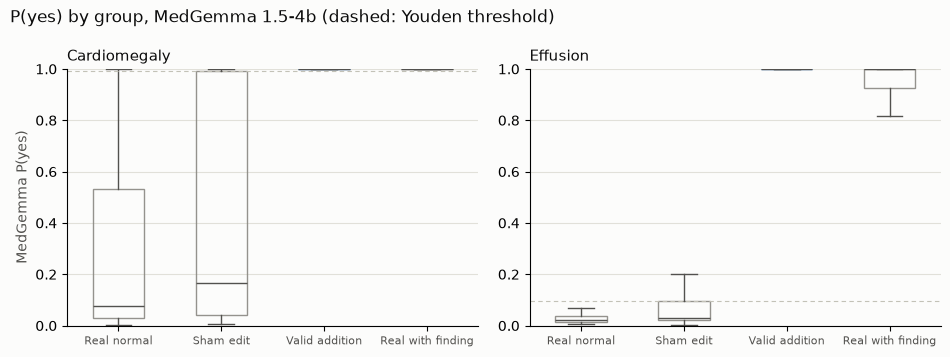

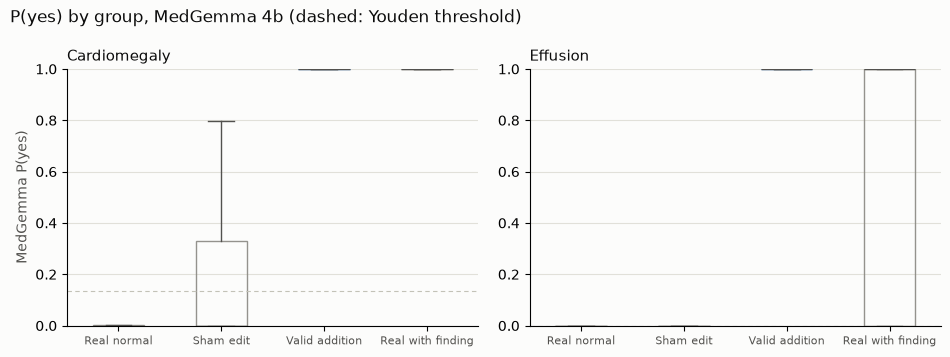

,model,finding,Real normal,Sham edit,Valid addition,Real with finding
0,1.5-4b,cardiomegaly,0.076,0.165,1.0,1.0
1,1.5-4b,effusion,0.020,0.029,1.0,1.0
2,4b,cardiomegaly,0.000,0.000,1.0,1.0
3,4b,effusion,0.000,0.000,1.0,1.0


In [6]:
groups = [("Real normal", "original"), ("Sham edit", "sham"), ("Valid addition", "edit"),
          ("Real with finding", "real_finding")]
for m in models:
    findings = sorted(wide[m]["finding"].unique())
    fig, axes = plt.subplots(1, len(findings), figsize=(4.8 * len(findings), 3.6), facecolor=SURFACE,
                             squeeze=False)
    for ax, finding in zip(axes[0], findings):
        g = wide[m][(wide[m]["finding"] == finding) & (wide[m]["phrasing"] == 0)]
        data = [g.loc[g["valid"], col] if col == "edit" else g[col] for _, col in groups]
        parts = ax.boxplot(data, widths=0.5, showfliers=False, patch_artist=True)
        for k, box in enumerate(parts["boxes"]):
            box.set(facecolor=ACCENT if groups[k][1] == "edit" else "none",
                    edgecolor=ACCENT if groups[k][1] == "edit" else MUTED, alpha=0.9)
        for key in ["whiskers", "caps", "medians"]:
            for line in parts[key]:
                line.set(color=INK_2, linewidth=1)
        ax.axhline(g["threshold"].iloc[0], color=AXIS, linewidth=0.8, linestyle=(0, (4, 3)))
        ax.set_xticks(range(1, 5), [name for name, _ in groups], fontsize=8, color=INK_2)
        ax.set_ylim(0, 1)
        ax.set_title(finding.capitalize(), loc="left", color=INK, fontsize=11)
        ax.set_facecolor(SURFACE)
        ax.grid(axis="y", color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
        for side in ["top", "right"]:
            ax.spines[side].set_visible(False)
    axes[0, 0].set_ylabel("MedGemma P(yes)", color=INK_2)
    fig.suptitle(f"P(yes) by group, MedGemma {m} (dashed: Youden threshold)", x=0.01, ha="left",
                 color=INK, fontsize=12)
    fig.tight_layout()
    fig.savefig(ROOT / "results" / f"audit_groups_{m}.png", dpi=200, facecolor=SURFACE)
    plt.show()

medians = pd.DataFrame([{"model": m, "finding": f, **{name: (g.loc[g["valid"], col] if col == "edit" else g[col]).median()
                         for name, col in groups}}
                        for m in models for f, g in wide[m][wide[m]["phrasing"] == 0].groupby("finding")]).round(3)
medians

## Sham breakdown: anatomical change or editing traces?

A sham uses the same mask, seed and edit path as the addition, with the normal prompt. The edit
checks measure what it did to the film: the classifier's score, the CTR (cardiomegaly) and the
aerated lung area in the mask (effusion; negative = shrinks). If sham flips come from real
anatomical change, they should follow these measures; if they come from editing traces, shams
with no measured change should flip too. Same eligibility as the flip rule: original below the
Youden threshold. All source films are used, whatever the validity of their addition.

In [7]:
checks = pd.read_csv(TABLES / "pairs_test.csv")
checks["classifier_before"] = checks["p_before:densenet121-res224-pc"]
checks["classifier_after"] = checks["p_after:densenet121-res224-pc"]
checks["d_classifier"] = checks["classifier_after"] - checks["classifier_before"]
checks["d_ctr"] = checks["ctr_after"] - checks["ctr_before"]
sham_checks = checks[checks["kind"] == "sham"][["finding", "image", "valid", "classifiers_ok", "anatomy_ok",
                                                  "d_classifier", "classifier_after", "d_ctr", "lung_area_change"]]
sham_checks = sham_checks.rename(columns={"valid": "sham_valid"})

def no_change(d):
    """Shams with no measured change toward the finding: classifier score not up, and CTR not up
    (cardiomegaly) or lung area not down (effusion)."""
    anatomy = np.where(d["finding"] == "cardiomegaly", d["d_ctr"] <= 0, d["lung_area_change"] >= 0)
    return (d["d_classifier"] <= 0) & anatomy

rows = []
for m in models:
    w = wide[m].drop(columns="valid").merge(sham_checks, on=["finding", "image"])
    w = w[w["original"] < w["threshold"]].reset_index(drop=True)
    for (finding, phrasing), g in w.groupby(["finding", "phrasing"]):
        for subset, d in [("passes the checks", g[g["sham_valid"]]), ("fails the checks", g[~g["sham_valid"]]),
                          ("no measured change", g[no_change(g)])]:
            d = d.reset_index(drop=True)
            flip = lambda x: (x["sham"] > x["threshold"]).mean()
            lo, hi = patient_ci(d, flip) if len(d) > 1 else (np.nan, np.nan)
            shift = lambda x: (logit(x["sham"]) - logit(x["original"])).mean()
            slo, shi = patient_ci(d, shift) if len(d) > 1 else (np.nan, np.nan)
            rows.append({"model": m, "finding": finding, "phrasing": phrasing, "shams": subset, "n": len(d),
                         "flip_sham": flip(d), "ci_low": lo, "ci_high": hi,
                         "mean_change_log_odds": shift(d), "lo_ci_low": slo, "lo_ci_high": shi})
sham_table = pd.DataFrame(rows).round(3)
sham_table.to_csv(ROOT / "results" / "audit_sham_breakdown.csv", index=False)
sham_table

,model,finding,phrasing,shams,n,flip_sham,ci_low,ci_high,mean_change_log_odds,lo_ci_low,lo_ci_high
0,1.5-4b,cardiomegaly,0,passes the checks,16,0.938,0.812,1.000,13.366,11.857,14.858
1,1.5-4b,cardiomegaly,0,fails the checks,323,0.164,0.127,0.204,2.085,1.595,2.607
2,1.5-4b,cardiomegaly,0,no measured change,85,0.047,0.012,0.094,-0.354,-0.797,0.118
3,1.5-4b,cardiomegaly,1,passes the checks,16,0.938,0.812,1.000,12.179,9.632,14.853
4,1.5-4b,cardiomegaly,1,fails the checks,329,0.109,0.079,0.146,0.884,0.593,1.218
5,1.5-4b,cardiomegaly,1,no measured change,87,0.011,0.000,0.034,-0.381,-0.589,-0.194
6,1.5-4b,effusion,0,passes the checks,1,1.000,NaN,NaN,4.875,NaN,NaN
7,1.5-4b,effusion,0,fails the checks,518,0.143,0.110,0.172,0.811,0.661,0.956
8,1.5-4b,effusion,0,no measured change,141,0.085,0.043,0.135,0.382,0.241,0.543
9,1.5-4b,effusion,1,passes the checks,1,1.000,NaN,NaN,7.125,NaN,NaN


Flip rate of shams that fail the checks, by how much the sham moved the anatomy (cardiomegaly: CTR change).

In [8]:
rows = []
for m in models:
    w = wide[m].drop(columns="valid").merge(sham_checks, on=["finding", "image"])
    w = w[(w["original"] < w["threshold"]) & ~w["sham_valid"] & (w["finding"] == "cardiomegaly")].copy()
    w["CTR change"] = pd.cut(w["d_ctr"], [-1, 0, 0.02, 0.04, 0.06, 1],
                             labels=["<= 0", "0 to 0.02", "0.02 to 0.04", "0.04 to 0.06", "> 0.06"])
    t = w.groupby(["phrasing", "CTR change"], observed=True).apply(
        lambda g: pd.Series({"n": len(g), "flip_sham": (g["sham"] > g["threshold"]).mean()}), include_groups=False)
    rows.append(t.assign(model=m))
pd.concat(rows).reset_index().pivot_table(index="CTR change", columns=["model", "phrasing"],
                                          values=["n", "flip_sham"], observed=True).round(3)

flip_sham                           n                     
model           1.5-4b            4b        1.5-4b            4b       
phrasing             0      1      0      1      0      1      0      1
CTR change                                                             
<= 0             0.075  0.045  0.084  0.040  173.0  177.0  167.0  174.0
0 to 0.02        0.063  0.025  0.039  0.038   79.0   80.0   76.0   78.0
0.02 to 0.04     0.259  0.250  0.321  0.250   27.0   28.0   28.0   28.0
0.04 to 0.06     0.409  0.182  0.364  0.435   22.0   22.0   22.0   23.0
> 0.06           0.864  0.682  0.864  0.636   22.0   22.0   22.0   22.0

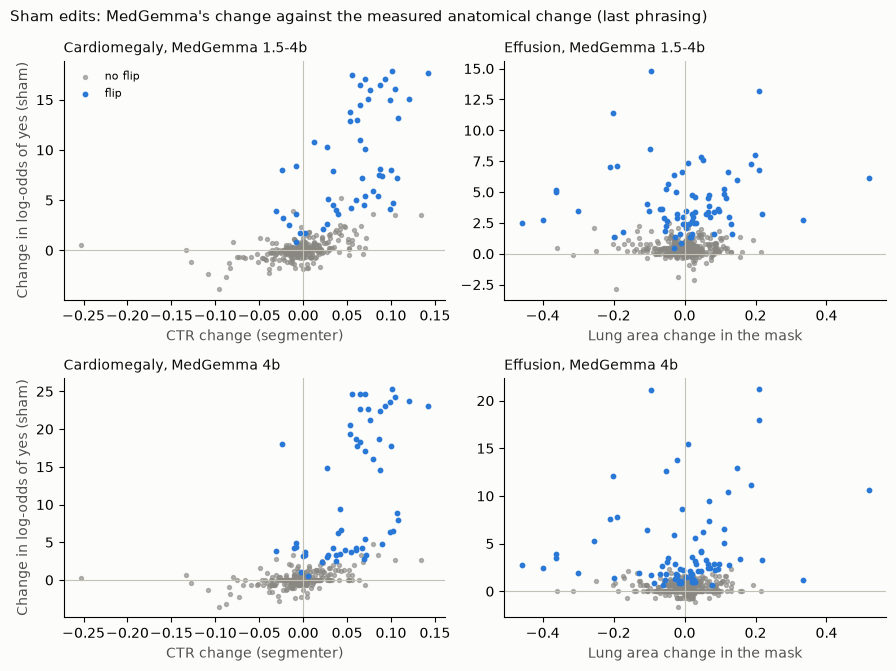

In [9]:
fig, axes = plt.subplots(len(models), 2, figsize=(9, 3.4 * len(models)), facecolor=SURFACE, squeeze=False)
for i, m in enumerate(models):
    w = wide[m].drop(columns="valid").merge(sham_checks, on=["finding", "image"])
    w = w[(w["phrasing"] == w.groupby("finding")["phrasing"].transform("max")) & (w["original"] < w["threshold"])]
    for ax, (finding, x, label) in zip(axes[i], [("cardiomegaly", "d_ctr", "CTR change (segmenter)"),
                                                  ("effusion", "lung_area_change", "Lung area change in the mask")]):
        g = w[w["finding"] == finding]
        flipped = g["sham"] > g["threshold"]
        y = logit(g["sham"]) - logit(g["original"])
        ax.scatter(g.loc[~flipped, x], y[~flipped], s=8, color=MUTED, alpha=0.6, label="no flip")
        ax.scatter(g.loc[flipped, x], y[flipped], s=10, color=ACCENT, label="flip")
        ax.axhline(0, color=AXIS, linewidth=0.8)
        ax.axvline(0, color=AXIS, linewidth=0.8)
        ax.set_xlabel(label, color=INK_2)
        ax.set_title(f"{finding.capitalize()}, MedGemma {m}", loc="left", color=INK, fontsize=10)
        ax.set_facecolor(SURFACE)
        for side in ["top", "right"]:
            ax.spines[side].set_visible(False)
    axes[i, 0].set_ylabel("Change in log-odds of yes (sham)", color=INK_2)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Sham edits: MedGemma's change against the measured anatomical change (last phrasing)",
             x=0.01, ha="left", color=INK, fontsize=11)
fig.tight_layout()
fig.savefig(ROOT / "results" / "audit_sham_vs_anatomy.png", dpi=200, facecolor=SURFACE)
plt.show()

## Four groups: the edit checks' own measures

The classifier's score and the segmenter's CTR for real normal films (originals), shams and valid
additions. Real films with the finding get these measures in the dose-response run (not scored
yet).

In [10]:
rows = []
for finding, g in checks.groupby("finding"):
    for name, d, col in [("Real normal", g[g["kind"] == "edit"], "before"), ("Sham edit", g[g["kind"] == "sham"], "after"),
                         ("Valid addition", g[(g["kind"] == "edit") & g["valid"]], "after")]:
        row = {"finding": finding, "group": name, "n": len(d),
               "classifier_median": d[f"p_{col}:densenet121-res224-pc"].median()}
        if finding == "cardiomegaly":
            row["ctr_median"] = d[f"ctr_{col}"].median()
            row["share_ctr_above_0.5"] = (d[f"ctr_{col}"] > 0.5).mean()
        rows.append(row)
pd.DataFrame(rows).round(3)

,finding,group,n,classifier_median,ctr_median,share_ctr_above_0.5
0,cardiomegaly,Real normal,380,0.016,0.422,0.005
1,cardiomegaly,Sham edit,380,0.029,0.423,0.058
2,cardiomegaly,Valid addition,308,0.624,0.551,1.000
3,effusion,Real normal,600,0.048,NaN,NaN
4,effusion,Sham edit,600,0.052,NaN,NaN
5,effusion,Valid addition,179,0.920,NaN,NaN


## Reliability of P(yes)

Test originals (normal, label 0) and the real films with the finding shown as a control (label 1).
Half the images carry the finding, far more than in practice, so this shows the shape of the
miscalibration, not its size at real prevalence. The real films with the finding are drawn with
replacement, so some appear several times.

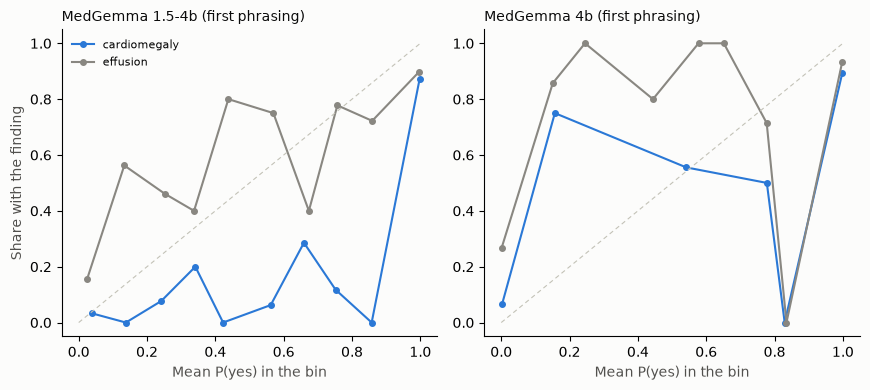

,model,finding,share_p_below_0.01,share_p_above_0.99,observed_rate_when_p_below_0.01
0,1.5-4b,cardiomegaly,0.016,0.516,0.000
1,1.5-4b,effusion,0.019,0.392,0.130
2,4b,cardiomegaly,0.438,0.486,0.063
3,4b,effusion,0.635,0.314,0.260


In [11]:
bins = np.linspace(0, 1, 11)
fig, axes = plt.subplots(1, len(models), figsize=(4.4 * len(models), 4), facecolor=SURFACE, squeeze=False)
rows = []
for ax, m in zip(axes[0], models):
    w = wide[m][wide[m]["phrasing"] == 0]
    for finding, g in w.groupby("finding"):
        p = np.concatenate([g["original"], g["real_finding"]])
        y = np.concatenate([np.zeros(len(g)), np.ones(len(g))])
        k = np.clip(np.digitize(p, bins) - 1, 0, 9)
        mean_p = [p[k == b].mean() for b in range(10) if (k == b).any()]
        observed = [y[k == b].mean() for b in range(10) if (k == b).any()]
        ax.plot(mean_p, observed, marker="o", markersize=4, color=ACCENT if finding == "cardiomegaly" else MUTED,
                label=finding)
        rows.append({"model": m, "finding": finding, "share_p_below_0.01": (p < 0.01).mean(),
                     "share_p_above_0.99": (p > 0.99).mean(),
                     "observed_rate_when_p_below_0.01": y[p < 0.01].mean() if (p < 0.01).any() else np.nan})
    ax.plot([0, 1], [0, 1], color=AXIS, linewidth=0.8, linestyle=(0, (4, 3)))
    ax.set_xlabel("Mean P(yes) in the bin", color=INK_2)
    ax.set_title(f"MedGemma {m} (first phrasing)", loc="left", color=INK, fontsize=10)
    ax.set_facecolor(SURFACE)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
axes[0, 0].set_ylabel("Share with the finding", color=INK_2)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(ROOT / "results" / "audit_reliability.png", dpi=200, facecolor=SURFACE)
plt.show()
pd.DataFrame(rows).round(3)

## Day-4 decision rule, step 1 (PLAN.md, fixed before these results)

Step 1 applies if shams that fail the addition checks flip with a 95% CI lower bound above 5%, for
both phrasings of at least one model and finding.

In [12]:
f = sham_table[sham_table["shams"] == "fails the checks"]
hit = f.groupby(["model", "finding"]).apply(
    lambda g: pd.Series({"phrasings": len(g), "all_ci_low_above_5%": bool((g["ci_low"] > 0.05).all()) and len(g) == 2}),
    include_groups=False)
print(hit.to_string())
print("Step 1 applies:", bool(hit["all_ci_low_above_5%"].any()))

                     phrasings  all_ci_low_above_5%
model  finding                                     
1.5-4b cardiomegaly          2                 True
       effusion              2                 True
4b     cardiomegaly          2                 True
       effusion              1                False
Step 1 applies: True


## Takeaways

In [13]:
for m in models:
    for finding in sorted(wide[m]["finding"].unique()):
        r = flips[(flips["model"] == m) & (flips["finding"] == finding) & (flips["phrasing"] == 0)
                  & (flips["subset"] == "all") & (flips["threshold"] == "Youden")]
        c = controls[(controls["model"] == m) & (controls["finding"] == finding) & (controls["phrasing"] == 0)]
        if len(r) and len(c):
            r, c = r.iloc[0], c.iloc[0]
            print(f"MedGemma {m}, {finding}: flip rate {r['flip_edit']:.0%} (95% CI {r['ci_low']:.0%}-{r['ci_high']:.0%}, "
                  f"n = {r['n_eligible']}), sham {r['flip_sham']:.0%}; 'yes' on blank {c['blank']:.0%}, "
                  f"shuffled {c['shuffled']:.0%}, real films with the finding {c['real_finding']:.0%}.")

MedGemma 1.5-4b, cardiomegaly: flip rate 100% (95% CI 100%-100%, n = 270), sham 22%; 'yes' on blank 0%, shuffled 0%, real films with the finding 92%.
MedGemma 1.5-4b, effusion: flip rate 100% (95% CI 100%-100%, n = 146), sham 11%; 'yes' on blank 0%, shuffled 3%, real films with the finding 84%.
MedGemma 4b, cardiomegaly: flip rate 100% (95% CI 100%-100%, n = 263), sham 24%; 'yes' on blank 0%, shuffled 0%, real films with the finding 94%.
